In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,roc_curve,auc

In [15]:
#uploading data in the code
df = pd.read_csv("HealthDiseas_cleaaned.csv")
print(df.head())
print(df.info())

        Age  Sex  RestingBP  Cholesterol  FastingBS     MaxHR  ExerciseAngina  \
0  0.244898    1   0.500000     0.393822          0  0.788732               0   
1  0.428571    0   0.666667     0.183398          0  0.676056               0   
2  0.183673    1   0.416667     0.382239          0  0.267606               0   
3  0.408163    0   0.483333     0.249035          0  0.338028               1   
4  0.530612    1   0.583333     0.212355          0  0.436620               0   

   HeartDisease  
0             0  
1             1  
2             0  
3             1  
4             0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             916 non-null    float64
 1   Sex             916 non-null    int64  
 2   RestingBP       916 non-null    float64
 3   Cholesterol     916 non-null    float64
 4   FastingBS       916 non-nu

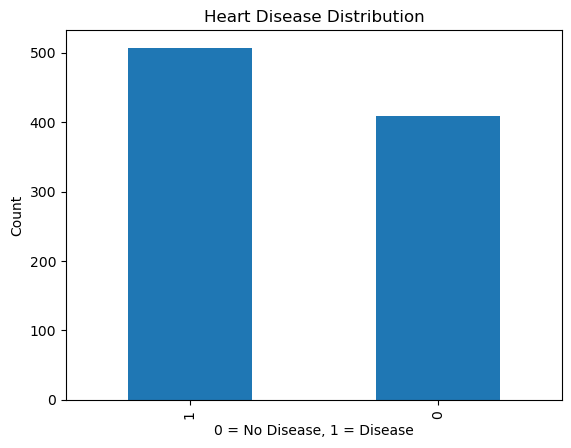

In [16]:
#Heart disease distribution to see how many have heart deasease and how many dosent
plt.figure()
df['HeartDisease'].value_counts().plot(kind='bar')
plt.title("Heart Disease Distribution")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Count")
plt.show()

In [6]:
#spliting data : features in X and target in Y
features = ['Sex', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina']
X = df[features]
y = df['HeartDisease']
#spliting X & Y into 50% test data and 50%train data
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.5, random_state=42)

In [11]:
#training model on train data
model = LogisticRegression()
model.fit(X_train, y_train)
#predicting with test data
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
#taking accuracy
accu= accuracy_score(y_test,y_pred)
con = confusion_matrix(y_test, y_pred)

In [12]:
print("Accuracy:", accu)
print("Confusion Matrix:\n",con)

Accuracy: 0.7860262008733624
Confusion Matrix:
 [[160  34]
 [ 64 200]]


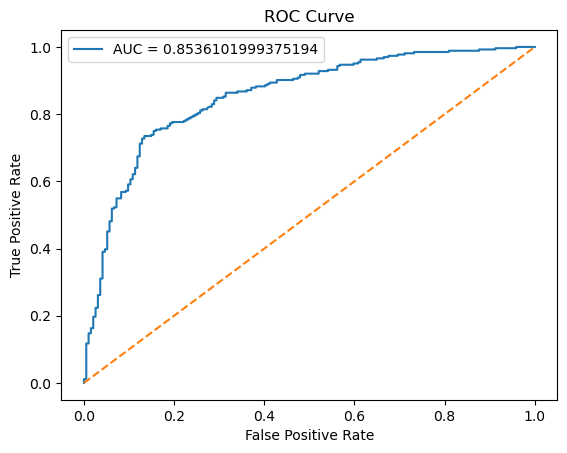

In [17]:
#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.plot([0, 1], [0, 1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()